# Redes Neuronales II — Parte 2
### Clasificación multiclase con TensorFlow + Keras: reconocer dígitos escritos a mano (MNIST)

---

**Universidad de Cundinamarca**

**CADI:** Deep Learning — Conceptos

**Estudiante:** Ruby Dayana Cárdenas Gómez

**Docente:** Nidia Stella García Roa

**Repositorio GitHub:** `https://github.com/RubyDayana/redes-neuronales-ii.git`

---

### ¿Qué se hace en este notebook?

En la Parte 1 programé las redes a mano con NumPy y las usé para decidir entre **dos** opciones (benigno o
maligno). Ahora doy dos pasos más:

1. **El problema tiene 10 respuestas posibles**, no dos: hay que reconocer qué dígito (del 0 al 9) hay en una
   imagen escrita a mano. A eso se le llama **clasificación multiclase**.
2. **Ya no programo la red a mano.** Uso **TensorFlow + Keras**, una herramienta que hace por mí lo que en la
   Parte 1 escribí paso a paso: crear las capas, pasar los datos hacia adelante, calcular la culpa de cada peso
   con retropropagación y corregirlos.

La red sigue siendo del mismo tipo que las de la Parte 1: capas de neuronas conectadas todas con todas (capas
"densas"), con ReLU en el medio. **No se usan redes convolucionales.**

| | Parte 1 (NumPy) | Parte 2 (Keras) |
|---|---|---|
| Problema | Benigno / maligno (2 respuestas) | Dígito 0–9 (10 respuestas) |
| Entradas por ejemplo | 30 medidas | 784 píxeles (una imagen de 28 × 28) |
| Ejemplos | 569 | 70 000 |
| Neurona(s) de salida | 1 con sigmoide | 10 con softmax |
| ¿Quién hace la retropropagación? | Yo, línea por línea | Keras, automáticamente |

---
## 1. Los datos: MNIST

**MNIST** es el conjunto de datos más famoso para empezar en Deep Learning. Son **70 000 imágenes** de dígitos
escritos a mano por distintas personas, cada una de 28 × 28 píxeles en escala de grises. Ya viene dividido:
60 000 imágenes para entrenar y 10 000 para probar.

Keras lo descarga con una sola línea.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(42)   # para que los resultados no cambien cada vez que se ejecuta

print("TensorFlow versión:", tf.__version__)
print("Keras versión     :", keras.__version__)

(X_ent, Y_ent), (X_pru, Y_pru) = keras.datasets.mnist.load_data()

print()
print("Imágenes de entrenamiento:", X_ent.shape, "->", X_ent.shape[0], "imágenes de", X_ent.shape[1], "x", X_ent.shape[2], "píxeles")
print("Etiquetas de entrenamiento:", Y_ent.shape)
print("Imágenes de prueba        :", X_pru.shape)
print("Etiquetas de prueba       :", Y_pru.shape)
print()
print("Primeras 10 etiquetas:", Y_ent[:10])
print("Valor mínimo y máximo de un píxel:", X_ent.min(), "y", X_ent.max())

TensorFlow versión: 2.21.0
Keras versión     : 3.15.1



Imágenes de entrenamiento: (60000, 28, 28) -> 60000 imágenes de 28 x 28 píxeles
Etiquetas de entrenamiento: (60000,)
Imágenes de prueba        : (10000, 28, 28)
Etiquetas de prueba       : (10000,)

Primeras 10 etiquetas: [5 0 4 1 9 2 1 3 1 4]
Valor mínimo y máximo de un píxel: 0 y 255


### 1.1. ¿Cómo se ven?

Cada imagen es una cuadrícula de 28 × 28 números entre 0 (negro) y 255 (blanco). La etiqueta es el dígito que
la persona escribió.

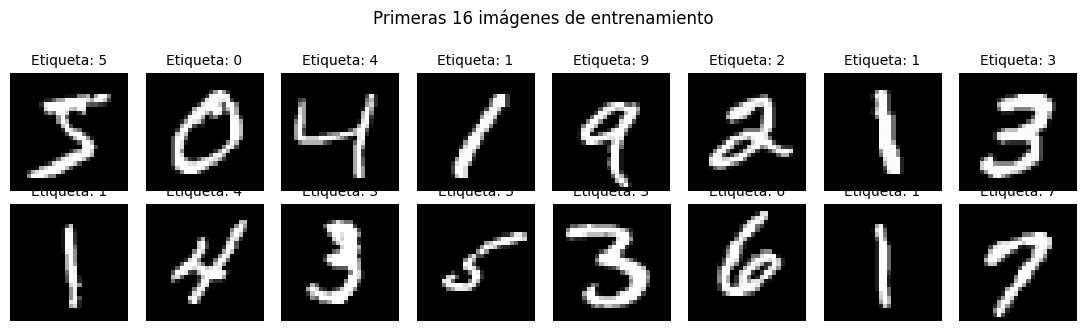

Cantidad de imágenes por dígito en entrenamiento:
  Dígito 0: 5923
  Dígito 1: 6742
  Dígito 2: 5958
  Dígito 3: 6131
  Dígito 4: 5842
  Dígito 5: 5421
  Dígito 6: 5918
  Dígito 7: 6265
  Dígito 8: 5851
  Dígito 9: 5949


In [2]:
fig, ejes = plt.subplots(2, 8, figsize=(11, 3.2))
for i, eje in enumerate(ejes.ravel()):
    eje.imshow(X_ent[i], cmap="gray")
    eje.set_title(f"Etiqueta: {Y_ent[i]}", fontsize=10)
    eje.axis("off")
plt.suptitle("Primeras 16 imágenes de entrenamiento", y=1.02)
plt.tight_layout(); plt.show()

# ¿Cuántas imágenes hay de cada dígito?
valores, conteos = np.unique(Y_ent, return_counts=True)
print("Cantidad de imágenes por dígito en entrenamiento:")
for v, c in zip(valores, conteos):
    print(f"  Dígito {v}: {c}")

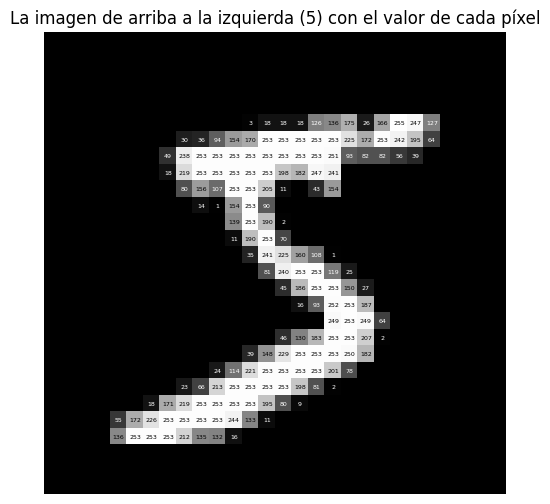

In [3]:
# Una imagen vista como números: así es como la ve la red
plt.figure(figsize=(6, 6))
plt.imshow(X_ent[0], cmap="gray")
for fila in range(28):
    for col in range(28):
        v = X_ent[0][fila, col]
        if v > 0:
            plt.text(col, fila, str(v), ha="center", va="center", fontsize=4.5,
                     color="black" if v > 128 else "white")
plt.title(f"La imagen de arriba a la izquierda ({Y_ent[0]}) con el valor de cada píxel")
plt.axis("off"); plt.show()

---
## 2. Preparar los datos

Se necesitan dos ajustes antes de entrenar.

**1. Aplanar la imagen.**
Las redes de la Parte 1 recibían una fila de números por ejemplo (30 medidas). Aquí cada ejemplo es una
cuadrícula de 28 × 28. Como no vamos a usar redes convolucionales (que trabajan con la cuadrícula), lo que se
hace es **estirar la imagen en una sola fila de 784 números** (28 × 28 = 784). La red no sabe que era una
imagen: para ella son 784 entradas, igual que antes eran 30.

**2. Llevar los píxeles a una escala de 0 a 1.**
Igual que se normalizaron las medidas de los tumores. Como todos los píxeles van de 0 a 255, basta con dividir
por 255.

In [4]:
# 1) Aplanar: de (60000, 28, 28) a (60000, 784)
X_ent_plano = X_ent.reshape(X_ent.shape[0], 784)
X_pru_plano = X_pru.reshape(X_pru.shape[0], 784)

# 2) Escalar: de 0-255 a 0-1
X_ent_plano = X_ent_plano.astype("float32") / 255.0
X_pru_plano = X_pru_plano.astype("float32") / 255.0

print("Antes :", X_ent.shape, " valores entre", X_ent.min(), "y", X_ent.max())
print("Ahora :", X_ent_plano.shape, " valores entre", X_ent_plano.min(), "y", X_ent_plano.max())

Antes : (60000, 28, 28)  valores entre 0 y 255
Ahora : (60000, 784)  valores entre 0.0 y 1.0


### 2.1. Binaria vs. multiclase: ¿qué cambia en la salida?

Este es el cambio de fondo respecto a la Parte 1.

| | Clasificación binaria (Parte 1) | Clasificación multiclase (aquí) |
|---|---|---|
| Respuestas posibles | 2 | 10 |
| Neuronas de salida | **1** | **10**, una por dígito |
| Función de la salida | Sigmoide: un número entre 0 y 1 | **Softmax**: 10 números que suman 1 |
| Cómo se lee | "87 % seguro que es benigno" | "3 % que es un 0, 1 % que es un 1, ..., 91 % que es un 7" |
| Respuesta final | Si pasa de 0.5 es 1, si no es 0 | El dígito que tenga el porcentaje más alto |
| Medida del error | Entropía cruzada binaria | Entropía cruzada (la misma idea, para 10 opciones) |

**Softmax** es la versión de la sigmoide para varias opciones: toma las 10 salidas y las convierte en
porcentajes que suman 100 %. Así la red no solo dice "es un 7", sino qué tan segura está y cuál era su segunda
opción.

Las etiquetas se quedan como están (un número del 0 al 9): Keras sabe interpretarlas.

---
## 3. Construir la red

En la Parte 1 una red se creaba con `crear_red([30, 16, 1])`. En Keras se hace de forma parecida, capa por
capa, con `Sequential`. La red que voy a usar es:

```
   784 entradas  ->  128 neuronas [ReLU]  ->  64 neuronas [ReLU]  ->  10 salidas [Softmax]
   (los píxeles)       capa oculta 1           capa oculta 2          una por dígito
```

Dos capas ocultas con ReLU (por lo que aprendí en la Parte 1: aprende más rápido) y la salida con softmax.
`Dense` significa que cada neurona está conectada con **todas** las de la capa anterior, exactamente como las
capas de la Parte 1.

In [5]:
modelo = keras.Sequential([
    keras.layers.Input(shape=(784,)),                  # 784 entradas: los píxeles
    keras.layers.Dense(128, activation="relu"),        # capa oculta 1
    keras.layers.Dense(64,  activation="relu"),        # capa oculta 2
    keras.layers.Dense(10,  activation="softmax"),     # salida: un porcentaje por dígito
], name="red_densa_mnist")

modelo.summary()

Model: "red_densa_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### 3.1. ¿De dónde salen esos números de parámetros?

Los "parámetros" son los pesos y los sesgos, los mismos `W` y `b` de la Parte 1. Se pueden calcular a mano:

- Capa 1: 784 entradas × 128 neuronas + 128 sesgos = **100 480**
- Capa 2: 128 × 64 + 64 = **8 256**
- Capa 3: 64 × 10 + 10 = **650**

En total **109 386** números que la red tiene que ajustar. La red de la Parte 1 tenía 513. Por eso se agradece
que Keras haga la retropropagación sola.

---
## 4. Entrenar

Antes de entrenar hay que decirle a Keras tres cosas con `compile`:

- **`optimizer="adam"`**: cómo corregir los pesos. En la Parte 1 usé descenso del gradiente con una tasa de
  aprendizaje fija. Adam es una versión más inteligente que ajusta el tamaño del paso para cada peso por su
  cuenta: da pasos grandes cuando está lejos y pequeños cuando se acerca.
- **`loss="sparse_categorical_crossentropy"`**: cómo medir el error. Es la entropía cruzada para varias clases.
  "Sparse" solo significa que las etiquetas vienen como un número (el 7) y no como una lista de diez casillas.
- **`metrics=["accuracy"]`**: qué mostrar mientras entrena. La exactitud, el porcentaje de aciertos.

Después, `fit` hace todo el ciclo que en la Parte 1 escribí a mano: hacia adelante, medir el error, hacia
atrás, corregir. Lo hace por grupos de 32 imágenes y durante 10 épocas. Además guardo el 10 % de las imágenes
de entrenamiento para ir midiendo, época por época, cómo le va con imágenes que no está usando para aprender
(*validación*).

In [6]:
modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

historia = modelo.fit(
    X_ent_plano, Y_ent,
    epochs=10,
    batch_size=32,
    validation_split=0.1,     # 10 % de las imágenes se aparta para validar
    verbose=2,
)

Epoch 1/10


1688/1688 - 10s - 6ms/step - accuracy: 0.9251 - loss: 0.2552 - val_accuracy: 0.9653 - val_loss: 0.1120


Epoch 2/10


1688/1688 - 10s - 6ms/step - accuracy: 0.9671 - loss: 0.1085 - val_accuracy: 0.9718 - val_loss: 0.0986


Epoch 3/10


...

1688/1688 - 10s - 6ms/step - accuracy: 0.9926 - loss: 0.0235 - val_accuracy: 0.9747 - val_loss: 0.1215


Epoch 9/10


1688/1688 - 9s - 6ms/step - accuracy: 0.9930 - loss: 0.0203 - val_accuracy: 0.9712 - val_loss: 0.1442


Epoch 10/10


1688/1688 - 6s - 3ms/step - accuracy: 0.9931 - loss: 0.0199 - val_accuracy: 0.9768 - val_loss: 0.1249


### 4.1. Cómo fue aprendiendo

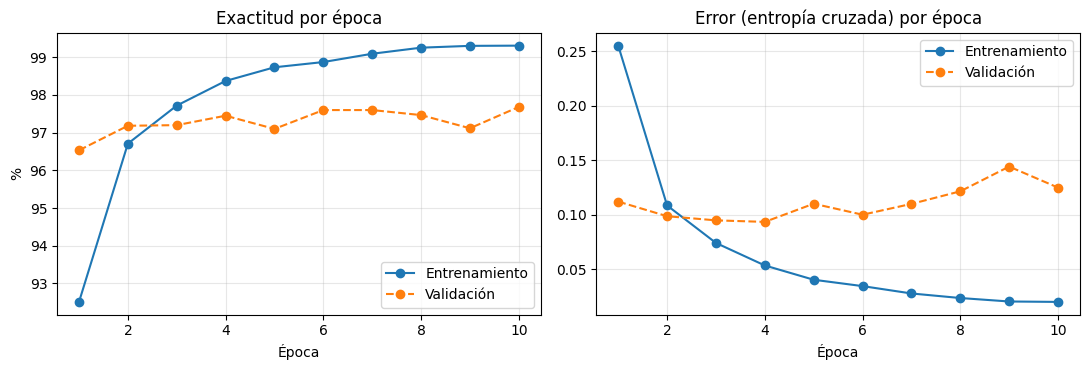

Exactitud final en entrenamiento: 99.31 %
Exactitud final en validación   : 97.68 %


In [7]:
h = historia.history
epocas = range(1, len(h["loss"]) + 1)

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))

ejes[0].plot(epocas, np.array(h["accuracy"]) * 100, marker="o", label="Entrenamiento")
ejes[0].plot(epocas, np.array(h["val_accuracy"]) * 100, marker="o", linestyle="--", label="Validación")
ejes[0].set_title("Exactitud por época"); ejes[0].set_xlabel("Época"); ejes[0].set_ylabel("%")
ejes[0].legend(); ejes[0].grid(alpha=.3)

ejes[1].plot(epocas, h["loss"], marker="o", label="Entrenamiento")
ejes[1].plot(epocas, h["val_loss"], marker="o", linestyle="--", label="Validación")
ejes[1].set_title("Error (entropía cruzada) por época"); ejes[1].set_xlabel("Época")
ejes[1].legend(); ejes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

print(f"Exactitud final en entrenamiento: {h['accuracy'][-1]*100:.2f} %")
print(f"Exactitud final en validación   : {h['val_accuracy'][-1]*100:.2f} %")

La red aprende casi todo en las primeras dos o tres épocas y después va afinando. La línea de entrenamiento
sube un poco más que la de validación: eso es normal.

Hay un detalle que vale la pena mirar en la gráfica de la derecha: el error de entrenamiento sigue bajando
hasta el final, pero el de validación deja de bajar más o menos en la época 4 y empieza a subir despacio. Eso
es la señal de que la red empieza a **memorizar** las imágenes de entrenamiento en vez de seguir aprendiendo
el patrón (a esto se le llama *sobreajuste*). Todavía es leve, pero indica que con esta red no tiene mucho
sentido entrenar muchas más épocas.

---
## 5. Evaluar con las 10 000 imágenes de prueba

Estas imágenes la red **nunca** las vio, ni para aprender ni para validar. Este es el número que cuenta.

In [8]:
error_prueba, exactitud_prueba = modelo.evaluate(X_pru_plano, Y_pru, verbose=0)

print(f"Exactitud en PRUEBA: {exactitud_prueba*100:.2f} %")
print(f"Error en PRUEBA    : {error_prueba:.4f}")
print()
aciertos = int(round(exactitud_prueba * len(Y_pru)))
print(f"De 10 000 imágenes, la red acertó {aciertos} y se equivocó en {10000 - aciertos}.")

Exactitud en PRUEBA: 97.24 %
Error en PRUEBA    : 0.1150

De 10 000 imágenes, la red acertó 9724 y se equivocó en 276.


### 5.1. ¿En qué se equivoca? La matriz de confusión

En la Parte 1 la matriz era de 2 × 2. Aquí es de 10 × 10: cada fila es el dígito real y cada columna lo que
respondió la red. Lo ideal es que todo esté en la diagonal.

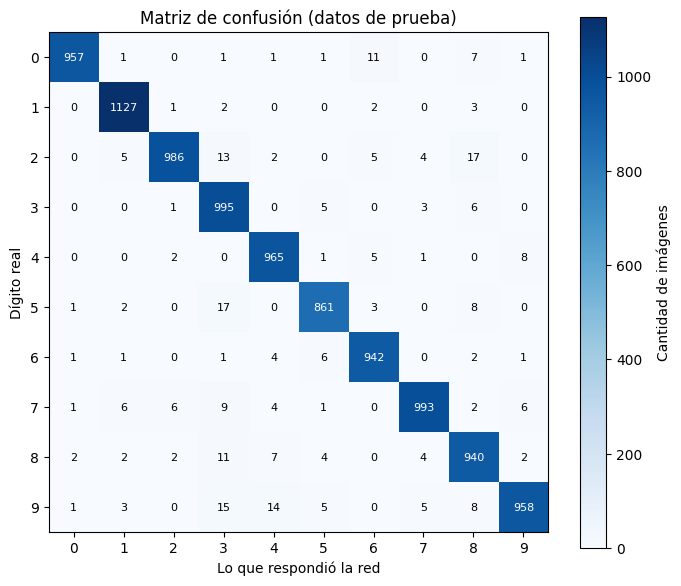

Las 5 confusiones más frecuentes:
  El 5 lo confundió con el 3: 17 veces
  El 2 lo confundió con el 8: 17 veces
  El 9 lo confundió con el 3: 15 veces
  El 9 lo confundió con el 4: 14 veces
  El 2 lo confundió con el 3: 13 veces

Exactitud por dígito:
  Dígito 0: 97.7 %
  Dígito 1: 99.3 %
  Dígito 2: 95.5 %
  Dígito 3: 98.5 %
  Dígito 4: 98.3 %
  Dígito 5: 96.5 %
  Dígito 6: 98.3 %
  Dígito 7: 96.6 %
  Dígito 8: 96.5 %
  Dígito 9: 94.9 %


In [9]:
# La red responde 10 porcentajes por imagen; nos quedamos con el más alto
probabilidades = modelo.predict(X_pru_plano, verbose=0)
predicciones = np.argmax(probabilidades, axis=1)

# Matriz de confusión 10 x 10
matriz = np.zeros((10, 10), dtype=int)
for real, pred in zip(Y_pru, predicciones):
    matriz[real, pred] += 1

plt.figure(figsize=(7, 6))
plt.imshow(matriz, cmap="Blues")
plt.colorbar(label="Cantidad de imágenes")
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Lo que respondió la red"); plt.ylabel("Dígito real")
plt.title("Matriz de confusión (datos de prueba)")
for i in range(10):
    for j in range(10):
        plt.text(j, i, matriz[i, j], ha="center", va="center", fontsize=8,
                 color="white" if matriz[i, j] > matriz.max() / 2 else "black")
plt.tight_layout(); plt.show()

# Los pares que más se confunden
confusiones = [(matriz[i, j], i, j) for i in range(10) for j in range(10) if i != j]
confusiones.sort(reverse=True)
print("Las 5 confusiones más frecuentes:")
for cantidad, real, pred in confusiones[:5]:
    print(f"  El {real} lo confundió con el {pred}: {cantidad} veces")

print()
print("Exactitud por dígito:")
for d in range(10):
    print(f"  Dígito {d}: {matriz[d, d] / matriz[d].sum() * 100:.1f} %")

### 5.2. Viendo las predicciones

Primero algunas imágenes al azar con lo que respondió la red y qué tan segura estaba. Después, solo las que
se equivocó: son las más interesantes, porque muchas veces uno también dudaría.

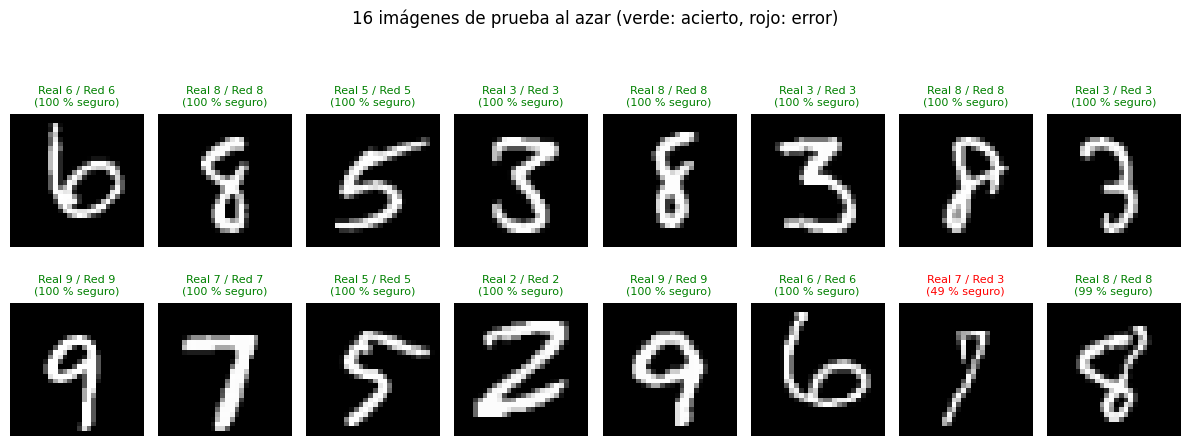

In [10]:
np.random.seed(7)
indices = np.random.choice(len(X_pru), 16, replace=False)

fig, ejes = plt.subplots(2, 8, figsize=(12, 4.6))
for idx, eje in zip(indices, ejes.ravel()):
    real, pred = Y_pru[idx], predicciones[idx]
    seguridad = probabilidades[idx][pred] * 100
    color = "green" if real == pred else "red"
    eje.imshow(X_pru[idx], cmap="gray")
    eje.set_title(f"Real {real} / Red {pred}\n({seguridad:.0f} % seguro)", fontsize=8, color=color)
    eje.axis("off")
plt.suptitle("16 imágenes de prueba al azar (verde: acierto, rojo: error)", y=1.04)
plt.tight_layout(); plt.show()

La red se equivocó en 276 de 10000 imágenes. Estas son las primeras 16:


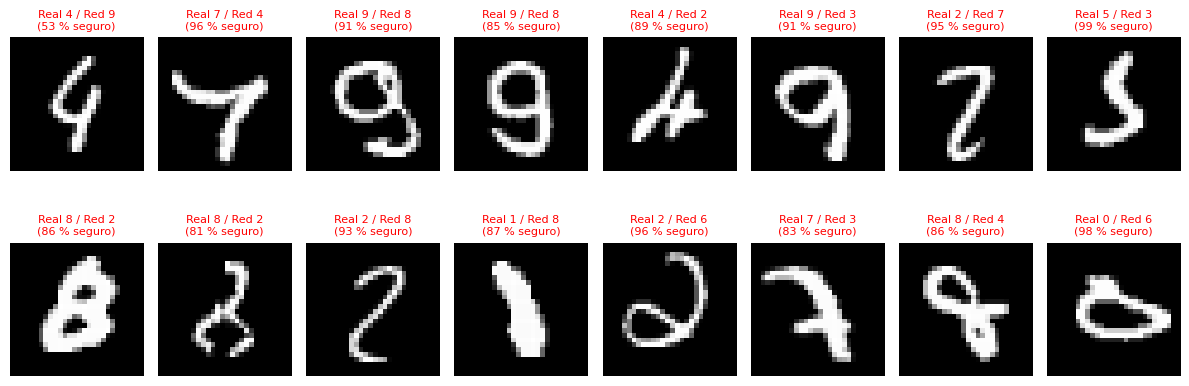

In [11]:
errores = np.where(predicciones != Y_pru)[0]
print(f"La red se equivocó en {len(errores)} de {len(Y_pru)} imágenes. Estas son las primeras 16:")

fig, ejes = plt.subplots(2, 8, figsize=(12, 4.6))
for idx, eje in zip(errores[:16], ejes.ravel()):
    real, pred = Y_pru[idx], predicciones[idx]
    seguridad = probabilidades[idx][pred] * 100
    eje.imshow(X_pru[idx], cmap="gray")
    eje.set_title(f"Real {real} / Red {pred}\n({seguridad:.0f} % seguro)", fontsize=8, color="red")
    eje.axis("off")
plt.tight_layout(); plt.show()

In [12]:
# ¿Qué responde la red para una sola imagen? Los 10 porcentajes completos
idx = errores[0]
print(f"Imagen #{idx}: el dígito real es {Y_pru[idx]} y la red respondió {predicciones[idx]}.")
print("Así repartió su confianza entre los 10 dígitos:")
for d, p in enumerate(probabilidades[idx]):
    barra = "#" * int(p * 40)
    print(f"  {d}: {p*100:5.1f} %  {barra}")

Imagen #115: el dígito real es 4 y la red respondió 9.
Así repartió su confianza entre los 10 dígitos:
  0:   0.0 %  
  1:   0.0 %  
  2:   0.0 %  
  3:   0.0 %  
  4:  46.9 %  ##################
  5:   0.0 %  
  6:   0.0 %  
  7:   0.0 %  
  8:   0.0 %  
  9:  53.1 %  #####################


---
## 6. Un experimento extra: ¿y si la capa oculta fuera sigmoide?

En la Parte 1 vi que ReLU aprendía más rápido que la sigmoide. ¿Se cumple también aquí, con Keras y un
problema mucho más grande? Entreno una red igual en todo, pero con sigmoide en las capas ocultas, y comparo
la exactitud de validación época por época y la exactitud final en prueba.

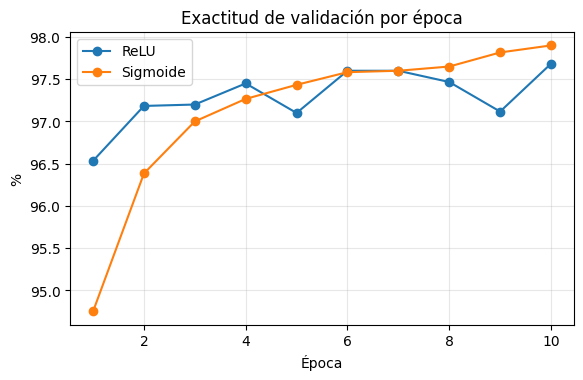

                     Época 1 (validación)   Final (prueba)
  ReLU                  96.53 %           97.24 %
  Sigmoide              94.75 %           97.62 %


In [13]:
keras.utils.set_random_seed(42)

modelo_sig = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(64,  activation="sigmoid"),
    keras.layers.Dense(10,  activation="softmax"),
], name="red_densa_sigmoide")

modelo_sig.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
historia_sig = modelo_sig.fit(X_ent_plano, Y_ent, epochs=10, batch_size=32, validation_split=0.1, verbose=0)

_, exactitud_sig = modelo_sig.evaluate(X_pru_plano, Y_pru, verbose=0)

plt.figure(figsize=(6.5, 3.8))
plt.plot(epocas, np.array(h["val_accuracy"]) * 100, marker="o", label="ReLU")
plt.plot(epocas, np.array(historia_sig.history["val_accuracy"]) * 100, marker="o", label="Sigmoide")
plt.title("Exactitud de validación por época"); plt.xlabel("Época"); plt.ylabel("%")
plt.legend(); plt.grid(alpha=.3); plt.show()

print("                     Época 1 (validación)   Final (prueba)")
print(f"  ReLU               {h['val_accuracy'][0]*100:8.2f} %          {exactitud_prueba*100:6.2f} %")
print(f"  Sigmoide           {historia_sig.history['val_accuracy'][0]*100:8.2f} %          {exactitud_sig*100:6.2f} %")

---
## 7. Resumen de resultados

| Modelo | Capas ocultas | Épocas | Exactitud en prueba |
|---|---|---|---|
| Red densa con ReLU (principal) | 128 + 64 | 10 | *(ver salida de la sección 5)* |
| Red densa con sigmoide (experimento) | 128 + 64 | 10 | *(ver salida de la sección 6)* |

Estos mismos valores se van a comparar en la Parte 3 con la misma red construida en PyTorch.

## 8. Conclusiones

1. **Pasar de 2 a 10 respuestas solo cambia la salida.** En vez de una neurona con sigmoide se usan diez con
   softmax, y la red responde con un porcentaje para cada dígito. Todo lo demás (capas densas, ReLU,
   retropropagación) es igual que en la Parte 1.

2. **Keras hace lo mismo que programé en NumPy, pero solo.** `Sequential` crea las capas, `compile` define
   cómo medir el error y cómo corregir, y `fit` ejecuta el ciclo de hacia adelante / hacia atrás / corregir.
   Entender la Parte 1 es lo que permite saber qué está pasando dentro de esas tres líneas.

3. **Una red densa, sin convoluciones, reconoce dígitos con más del 97 % de exactitud.** Con solo 784 números
   por imagen, sin saber siquiera que son píxeles, la red acierta más de 9 700 de 10 000 imágenes que nunca vio.

4. **Los errores tienen sentido.** Las confusiones más comunes son entre dígitos que se parecen al escribirlos
   (4 y 9, 3 y 5, 2 y 8), y muchas de las imágenes en las que falla también las dudaría una persona.

5. **ReLU aprende más rápido, pero con 10 épocas las dos redes terminan parecidas.** Igual que en la Parte 1,
   la red con ReLU arranca con mucha mejor exactitud en la primera época. Sin embargo, al final del
   entrenamiento la sigmoide la alcanza y puede incluso quedar unas décimas por encima. La explicación está en
   la gráfica de la sección 4: la red con ReLU aprende tan rápido que desde la mitad del entrenamiento ya está
   empezando a memorizar, mientras que la sigmoide, más lenta, todavía va aprendiendo. La ventaja de ReLU es
   la velocidad; para aprovecharla bien habría que detener el entrenamiento antes o usar más datos.